# Diarka QAOA Portfolio — Notebook 01: Problem Formulation

**Week 2, Session 1.** Goal: build the classical baseline that every QAOA result later in the project will be measured against.

This notebook does four things:

1. Pulls four years of daily prices for an 8-asset FTSE 100 universe via `yfinance`.
2. Computes annualised mean returns and the covariance matrix.
3. Solves the portfolio problem three ways — continuous Markowitz (cvxpy), brute-force binary enumeration, and the qiskit-finance + NumPyMinimumEigensolver pipeline.
4. Saves the results to `data/processed/` so Session 2 can build the QUBO encoding on top.

The universe is deliberately drawn from seven different FTSE 100 sectors with one intentional sector overlap (BT-A and VOD) so the covariance matrix carries a non-trivial structure for QAOA to work against.

## 0. Setup

In [1]:
from __future__ import annotations
from pathlib import Path
import sys

# Make src/ importable from the notebooks/ folder.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import (
    FTSE_UNIVERSE,
    fetch_prices,
    compute_log_returns,
    annualise,
)
from src.classical import (
    solve_continuous_markowitz,
    solve_binary_brute_force,
    solve_binary_qiskit_finance,
)

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

FTSE_UNIVERSE

['HSBA.L', 'AZN.L', 'SHEL.L', 'ULVR.L', 'RIO.L', 'BT-A.L', 'VOD.L', 'DGE.L']

## 1. Pull four years of daily prices

The universe is set in `src/data.py`. We pull adjusted close prices (Yahoo's `auto_adjust=True`), forward-fill at most one missing day, and then drop any rows where at least one asset is still missing.

In [2]:
prices = fetch_prices(FTSE_UNIVERSE, years=4)
print(f"Pulled {len(prices)} trading days from {prices.index.min().date()} to {prices.index.max().date()}.")
print(f"Universe ({len(prices.columns)} assets): {list(prices.columns)}")
prices.tail()


1 Failed download:
['HSBA.L']: OperationalError('database is locked')


Pulled 0 trading days from NaT to NaT.
Universe (8 assets): ['HSBA.L', 'AZN.L', 'SHEL.L', 'ULVR.L', 'RIO.L', 'BT-A.L', 'VOD.L', 'DGE.L']


Ticker,HSBA.L,AZN.L,SHEL.L,ULVR.L,RIO.L,BT-A.L,VOD.L,DGE.L


In [ ]:
# Persist raw price panel for reproducibility.
raw_path = DATA_RAW / f"prices_{prices.index.min().date()}_{prices.index.max().date()}.csv"
prices.to_csv(raw_path)
print(f"Saved raw prices to {raw_path.relative_to(ROOT)}")

## 2. Exploratory data analysis

Three quick visual checks before we trust the data:

1. **Normalised price paths** — are any series flat, exploding, or visibly broken?
2. **Daily log-return distributions** — are they roughly stationary and free of obvious anomalies?
3. **Correlation matrix** — does it match intuition (banks correlated, telecoms correlated, defensive sectors decoupled)?

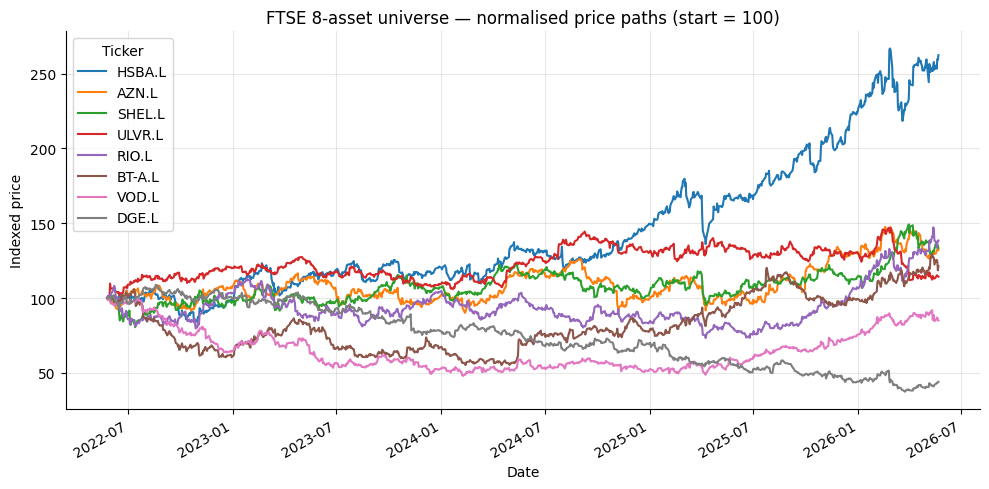

In [7]:
# 1. Normalised price paths (all start at 100).
normalised = prices / prices.iloc[0] * 100
ax = normalised.plot(title="FTSE 8-asset universe — normalised price paths (start = 100)")
ax.set_ylabel("Indexed price")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

1006 daily log-return observations.


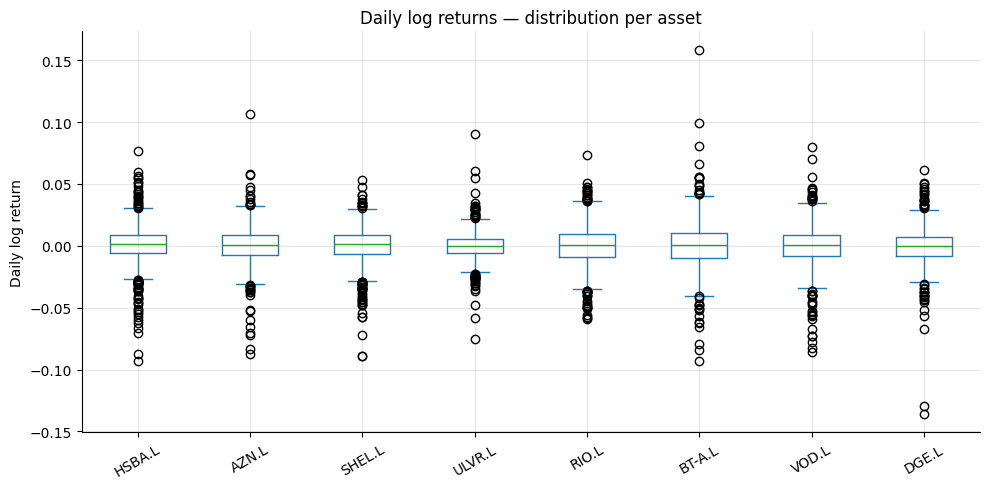

In [8]:
log_returns = compute_log_returns(prices)
print(f"{len(log_returns)} daily log-return observations.")

# 2. Daily log-return distributions (box plot is more readable than 8 histograms).
ax = log_returns.plot(
    kind="box", title="Daily log returns — distribution per asset", grid=True
)
ax.set_ylabel("Daily log return")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

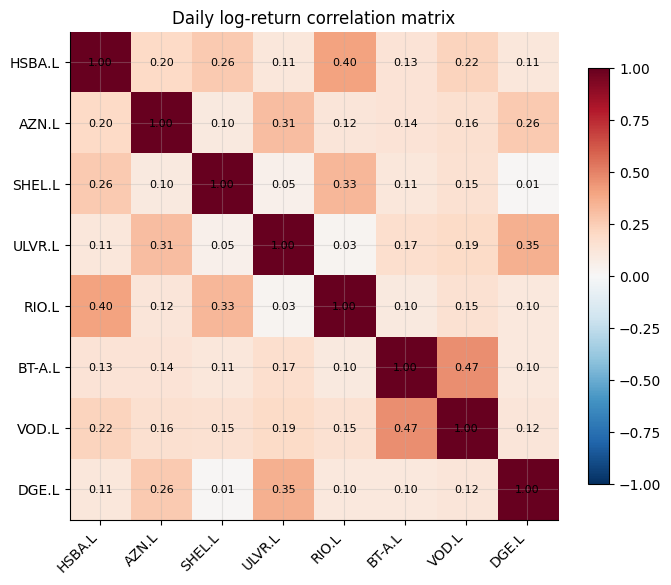

In [9]:
# 3. Correlation heatmap.
corr = log_returns.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Daily log-return correlation matrix")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 3. Annualised statistics

Mean returns and covariance are annualised by multiplying by 252 (UK & US trading-day convention). The covariance matrix is symmetrised in `annualise` to suppress floating-point asymmetry — both `cvxpy` and `qiskit-finance` will complain about a non-symmetric input.

In [10]:
stats = annualise(log_returns)

print("Annualised expected returns")
print("-" * 40)
for t, m in zip(stats.tickers, stats.mu):
    print(f"  {t:8s} {m:+.4f}")

print()
print("Annualised volatility (diagonal of sqrt(Σ))")
print("-" * 40)
for t, v in zip(stats.tickers, np.sqrt(np.diag(stats.sigma))):
    print(f"  {t:8s} {v:.4f}")

Annualised expected returns
----------------------------------------
  HSBA.L   +0.2416
  AZN.L    +0.0697
  SHEL.L   +0.0724
  ULVR.L   +0.0335
  RIO.L    +0.0815
  BT-A.L   +0.0485
  VOD.L    -0.0408
  DGE.L    -0.2055

Annualised volatility (diagonal of sqrt(Σ))
----------------------------------------
  HSBA.L   0.2447
  AZN.L    0.2350
  SHEL.L   0.2289
  ULVR.L   0.1744
  RIO.L    0.2556
  BT-A.L   0.2921
  VOD.L    0.2560
  DGE.L    0.2376


## 4. Classical solver A — continuous Markowitz (cvxpy)

The classical reference. Long-only, fully-invested, continuous weights. This is the standard efficient-frontier solution and serves as a sanity check on the data — if the result looks pathological, the problem is upstream of the optimiser.

In [11]:
RISK_AVERSION = 0.5  # q — same scalar reused across all three solvers
BUDGET = 4           # k-of-8 for the binary problem in solvers B and C

continuous = solve_continuous_markowitz(
    stats.mu, stats.sigma,
    risk_aversion=RISK_AVERSION,
    tickers=stats.tickers,
)
print(continuous.pretty())
print()
print("Continuous weights:")
for t, w in zip(stats.tickers, continuous.selection):
    bar = "█" * int(round(w * 40))
    print(f"  {t:8s} {w:6.3f}  {bar}")

Solver:           continuous_markowitz_cvxpy
Expected return:  0.2416  (annualised)
Expected risk:    0.2447  (annualised vol)
Sharpe (rf=0):    0.987
Objective value:  -0.211615
Selected:         HSBA.L

Continuous weights:
  HSBA.L    1.000  ████████████████████████████████████████
  AZN.L     0.000  
  SHEL.L    0.000  
  ULVR.L    0.000  
  RIO.L     0.000  
  BT-A.L    0.000  
  VOD.L     0.000  
  DGE.L     0.000  


## 5. Classical solver B — brute-force binary k-of-n

The discrete version, which is what QAOA will tackle. With ``n = 8`` and ``budget = 4`` there are only $\binom{8}{4} = 70$ feasible portfolios, so brute-force enumeration gives the exact ground-truth answer in milliseconds. *This is the number QAOA will be measured against.*

In [12]:
brute = solve_binary_brute_force(
    stats.mu, stats.sigma,
    budget=BUDGET,
    risk_factor=RISK_AVERSION,
    tickers=stats.tickers,
)
print(brute.pretty())

Solver:           brute_force_binary
Expected return:  0.4171  (annualised)
Expected risk:    0.5475  (annualised vol)
Sharpe (rf=0):    0.762
Objective value:  -0.267284
Selected:         HSBA.L, AZN.L, SHEL.L, ULVR.L


## 6. Classical solver C — qiskit-finance + NumPyMinimumEigensolver

Same problem, solved via the qiskit-finance pipeline. `PortfolioOptimization` builds a `QuadraticProgram`, the converter inside `MinimumEigenOptimizer` turns it into an Ising Hamiltonian, and `NumPyMinimumEigensolver` diagonalises that Hamiltonian exactly.

**Validation gate.** If solvers B and C disagree, either the encoding inside qiskit-finance has been misunderstood or the inputs differ. They should select the same assets and report the same objective value (to within solver tolerances).

In [15]:
qf = solve_binary_qiskit_finance(
    stats.mu, stats.sigma,
    budget=BUDGET,
    risk_factor=RISK_AVERSION,
    tickers=stats.tickers,
)
print(qf.pretty())

Solver:           qiskit_finance_numpy_eigensolver
Expected return:  0.4171  (annualised)
Expected risk:    0.5475  (annualised vol)
Sharpe (rf=0):    0.762
Objective value:  -0.267284
Selected:         HSBA.L, AZN.L, SHEL.L, ULVR.L


In [16]:
# Cross-check: do solvers B and C agree on the selected assets?
assert np.allclose(brute.selection, qf.selection), (
    "Brute-force and qiskit-finance solutions disagree — investigate before Session 2."
)
print("✓ Brute-force and qiskit-finance agree on the optimal binary selection.")
print(f"  Objective difference: {abs(brute.objective - qf.objective):.2e}")

✓ Brute-force and qiskit-finance agree on the optimal binary selection.
  Objective difference: 0.00e+00


## 7. Persist outputs for Session 2

Session 2 (QUBO encoding in `src/encoding.py`) and Session 3 (first QAOA run) both load these arrays. Saving them as `.npz` keeps the QUBO formulation deterministic regardless of when the notebook was last run against live Yahoo data.

In [17]:
stats.to_npz(DATA_PROCESSED / "portfolio_stats.npz")

np.savez(
    DATA_PROCESSED / "classical_solution.npz",
    selection=brute.selection,
    expected_return=brute.expected_return,
    expected_risk=brute.expected_risk,
    objective=brute.objective,
    risk_factor=RISK_AVERSION,
    budget=BUDGET,
    tickers=np.array(stats.tickers),
)

print("Saved:")
for p in sorted(DATA_PROCESSED.glob("*.npz")):
    print(f"  {p.relative_to(ROOT)}")

Saved:
  data/processed/classical_solution.npz
  data/processed/portfolio_stats.npz


## Session 1 — wrap-up

What this notebook has established:

- A clean, reproducible data pull for an 8-asset FTSE universe with a non-trivial covariance structure.
- Annualised $\mu$ and $\Sigma$, ready to be consumed by any optimiser.
- Three classical solutions that agree pairwise where they should (binary B vs. binary C) and differ where they should (continuous vs. binary).
- A persisted artefact under `data/processed/` that the rest of the project builds on.

**Next session (Session 2):** lift the binary objective into a hand-rolled QUBO in `src/encoding.py`, derive the Ising Hamiltonian explicitly (rather than via the qiskit-finance black box), and verify that the QUBO's ground state matches the brute-force selection above.